<h1>Clasificacion Random Forest en microprocesador 64 bits vb.net</h1>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split #para seleccionar lotes de entrenamiento y prueba
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest # para seleccionar las mejores caracteristicas
from sklearn.feature_selection import chi2, f_regression
from sklearn.preprocessing import MinMaxScaler

import pandas as pd
import numpy as np
from numpy import array

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import log_loss
from sklearn.metrics import recall_score
import statistics


import  tqdm#notebook_tqdm

from sklearn import preprocessing
# documentacion en: https://scikit-learn.org/stable/modules/svm.html#classification
import optuna
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split

In [2]:
def matriz_de_confusion(clases_reales, clases_predichas, titulo):
    """ Visualiza la matriz de confusión """
   
    matriz = confusion_matrix(clases_reales, clases_predichas)
    accuracy = accuracy_score(clases_reales, clases_predichas)
    maximo_valor=np.max(matriz);
    print(maximo_valor);
    #Código de matplotlib para graficar 
    plt.figure(figsize=(6, 6))
    matriz = pd.DataFrame(matriz,columns=["0 : Normal", "1 : Caudaloso","2 : Impacto piedras"])
    plt.matshow(matriz, cmap="summer", vmin=0, vmax=maximo_valor, fignum=1)
    plt.colorbar()
    plt.xticks(range(len(matriz.columns)), matriz.columns, rotation=45)
    plt.yticks(range(len(matriz.columns)), matriz.columns)
    #etiquetas = (("Verdaderos\nnegativos", "Falsos\npositivos"),
    #             ("Falsos\nnegativos", "Verdaderos\npositivos"))
    etiquetas = (("Verdad", "Falso","Falso"),
                ("Falso", "Verdad","Falso"),
                ("Falso", "Falso","Verdad"))
    
    plt.text(3.20, -0.30, titulo, fontsize=14, c="blue")
    plt.text(3.20, -0.10, "Exactitud: %0.2f" % accuracy, fontsize=14)
    for i in range(len(matriz.columns)):
        for j in range(len(matriz.columns)):
            plt.text(i, j + 0.14, str(matriz.iloc[i, j]),
                     fontsize=30, ha="center", va="center")
            plt.text(i, j - 0.25, etiquetas[i][j],
                     fontsize=11.5, ha="center", va="center")           
    plt.show()

In [3]:
def geometric_mean_score(y_true, y_pred):
    recalls = recall_score(y_true, y_pred, average=None); # recall por clase
    gmean = np.prod(recalls) ** (1.0 / len(recalls));   # raíz cúbica si hay 3 clases
    return gmean

In [4]:
def calcular_metricas(y_true, y_pred,num_evaluacion):
    metricas_reg1 = np.zeros((1,19));
    metricas_reg1[0,0]=num_evaluacion+1;
    metricas_reg1[0,1]=0;
    #1. Accuracy
    accuracy_valor=accuracy_score(clase_test, clase_prediccion);
    print(f"\nAccuracy: {accuracy_valor:.3f}");
    metricas_reg1[0,2]="{:.3f}".format(accuracy_valor);
    #En la clasificación de múltiples etiquetas, esta función calcula la precisión del subconjunto: 
    #el conjunto de etiquetas predicho para una muestra debe coincidir exactamente con el conjunto 
    #de etiquetas correspondiente en y_true
    
    #2. Loss
    loss=1-accuracy_valor;
    print(f"\nLoss: {loss:.3f}");
    metricas_reg1[0,3]="{:.3f}".format(loss);
    
    #3. F1 score
    f1_per_clase = f1_score(clase_test, clase_prediccion,average=None)
    print(f"\nf1_per_clase: {f1_per_clase[0]:.3f} {f1_per_clase[1]:.3f} {f1_per_clase[2]:.3f}");
    metricas_reg1[0,11]="{:.3f}".format(f1_per_clase[0]);metricas_reg1[0,12]="{:.3f}".format(f1_per_clase[1]);
    metricas_reg1[0,13]="{:.3f}".format(f1_per_clase[2]);
        
    #4. Balanced accuracy
    #La precisión equilibrada en problemas de clasificación binaria y multiclase para abordar conjuntos 
    #de datos desequilibrados. Se define como el promedio de recuperación obtenido en cada clase.
    #El mejor valor es 1 y el peor valor es 0 cuando el ajuste es falso.
    balanceado_acuracy=balanced_accuracy_score(clase_test, clase_prediccion);
    print(f"\nbalanceado accuracy: {balanceado_acuracy:.3f}");
    metricas_reg1[0,10]="{:.3f}".format(balanceado_acuracy);
    
    #5. Recall
    confusion_basi = confusion_matrix(clase_test, clase_prediccion)
    sensitivity =recall_score(clase_test, clase_prediccion, average=None);
    recall_normal=confusion_basi[0,0]/(confusion_basi[0,0]+confusion_basi[0,1]+confusion_basi[0,2]);#precision=vp1/(vp1+fp1+fp1)
    recall_cauda=confusion_basi[1,1]/(confusion_basi[1,0]+confusion_basi[1,1]+confusion_basi[1,2]);#precision=vp1/(vp1+fp1+fp1)
    recall_piedra=confusion_basi[2,2]/(confusion_basi[2,0]+confusion_basi[2,1]+confusion_basi[2,2]);#precision=vp1/(vp1+fp1+fp1)
    print(f"\nRecall nor-cau-pie:{recall_normal:.3f} {recall_cauda:.3f} {recall_piedra:.3f}");
    metricas_reg1[0,7]="{:.3f}".format(recall_normal);metricas_reg1[0,8]="{:.3f}".format(recall_cauda);
    metricas_reg1[0,9]="{:.3f}".format(recall_piedra);
    
    #6. presicion
    confusion_basi = confusion_matrix(clase_test, clase_prediccion)
    print(confusion_basi);
    presicion_normal=confusion_basi[0,0]/(confusion_basi[0,0]+confusion_basi[1,0]+confusion_basi[2,0]);#precision=vp1/(vp1+fp1+fp1)
    presicion_cauda=confusion_basi[1,1]/(confusion_basi[0,1]+confusion_basi[1,1]+confusion_basi[2,1]);#precision=vp1/(vp1+fp1+fp1)
    presicion_piedra=confusion_basi[2,2]/(confusion_basi[0,2]+confusion_basi[1,2]+confusion_basi[2,2]);#precision=vp1/(vp1+fp1+fp1)
    print(f"\nPresición nor-cau-pie:{presicion_normal:.3f} {presicion_cauda:.3f} {presicion_piedra:.3f}");
    metricas_reg1[0,4]="{:.3f}".format(presicion_normal);metricas_reg1[0,5]="{:.3f}".format(presicion_cauda);
    metricas_reg1[0,6]="{:.3f}".format(presicion_piedra);
    
    #specificity = tn / (tn + fp) #Verdaderos Positivos(TP)  --- Falsos Negativos(FN)
    specifi_normal=(confusion_basi[0,1]+confusion_basi[0,2])/(confusion_basi[0,0]+confusion_basi[0,1]+confusion_basi[0,2]);#precision=vp1/(vp1+fp1+fp1)
    specifi_cauda=(confusion_basi[1,0]+confusion_basi[1,2])/(confusion_basi[1,0]+confusion_basi[1,1]+confusion_basi[1,2]);#precision=vp1/(vp1+fp1+fp1)
    specifi_piedra=(confusion_basi[2,0]+confusion_basi[2,1])/(confusion_basi[2,0]+confusion_basi[2,1]+confusion_basi[2,2]);#precision=vp1/(vp1+fp1+fp1)
    print(f"\nSpecificity nor-cau-pie:{specifi_normal:.3f} {specifi_cauda:.3f} {specifi_piedra:.3f}");
    metricas_reg1[0,16]="{:.3f}".format(specifi_normal);metricas_reg1[0,17]="{:.3f}".format(specifi_cauda);
    metricas_reg1[0,18]="{:.3f}".format(specifi_piedra);
    
    #7. Calculate G-Mean
    media_geometrica=geometric_mean_score(clase_test, clase_prediccion);
    print(f"\nG-Mean:{media_geometrica:.3f}");
    metricas_reg1[0,15]="{:.3f}".format(media_geometrica);
    
    #8. Kappa
    kappa=cohen_kappa_score(clase_test, clase_prediccion); #cohen_kappa_score
    print(f"\nCohen’s kappa:{kappa:.3f}");
    metricas_reg1[0,14]="{:.3f}".format(kappa);
    
    return   metricas_reg1;

In [5]:
metricas_reg0 = np.zeros((1,19));
metricas_tabla= np.zeros((5,19));
col_caract=77;# 2 al 47 (45 caracteristicas)
parametros = []
entro_geni="gini";  # gini    o    entropy

<h2>1. Extracción de características desde archivo CSV</h2>

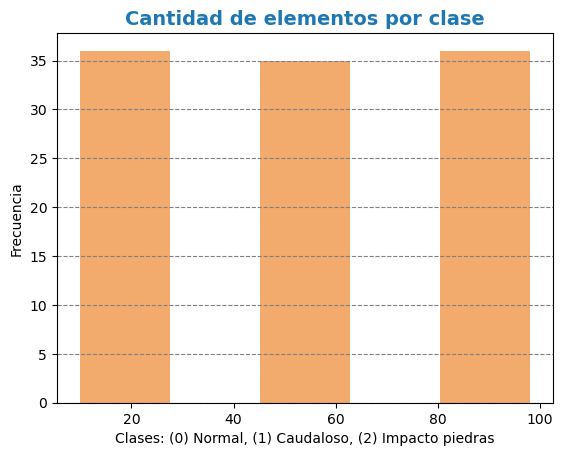

In [6]:
df = pd.read_csv('features_16agos2026_sismos_audio_unificado_csv.csv')
df.head(10) #muestra las 10 primeras filas
caracteristicas0= df.to_numpy();
col_caract=77;# 2 al 47 (45 caracteristicas)
caracteristicas1= caracteristicas0[:,2:col_caract];
clase= caracteristicas0[:,1];

plt.hist(clase, bins=3, color='#F2AB6D', rwidth=0.5)
plt.xlabel('Clases: (0) Normal, (1) Caudaloso, (2) Impacto piedras')
plt.ylabel('Frecuencia')
plt.title('Cantidad de elementos por clase', loc = "center", fontdict = {'fontsize':14, 'fontweight':'bold', 'color':'tab:blue'});
plt.grid(axis = 'y', color = 'gray', linestyle = 'dashed');
plt.show()

<h2>2. Análisis de componenets principales</h2>

In [ ]:
#_______________________lo siguiente para el análisis de componentes principales______________
from sklearn.decomposition import PCA
pca=PCA()
df3 = pd.DataFrame(caracteristicas0[:,2:col_caract]) #convertir matriz numpy en Dataframe
resultados_pca=pca.fit_transform(df3);
#print('Matriz de 10 caracteristicas:');
#print(df3);
#print('Matriz valores proyectados con los PCA de matriz de 10 caracteristicas:');
#print(resultados_pca);
print('Varianza explicada por cada componente:', pca.explained_variance_);
print('Proporción de la varianza explicada por cada componente:', pca.explained_variance_ratio_);
# la suma de los tres primeros componentes de pca.explained_variance_ratio_ debe generar un valor cercano al 100%

#ahora se grafican los PCA en plano 3d
fig = plt.figure(figsize=(12,8)) # Set the figure size to 8 inches wide-ancho and 6 inches tall -alto
ax = fig.add_subplot(projection='3d')
cant_filas=len(resultados_pca);
tipo_avenida=caracteristicas0[:,1];
elemento_clase_normal=0;
elemento_clase_caudaloso=0;
elemento_clase_impacto=0;
for i in range(cant_filas):
    if (tipo_avenida[i]==0):
        elemento_clase_normal=elemento_clase_normal+1;
    if (tipo_avenida[i]==1):
        elemento_clase_caudaloso=elemento_clase_caudaloso+1;
    if (tipo_avenida[i]==2):
        elemento_clase_impacto=elemento_clase_impacto+1;
for i in range(cant_filas):
    xs = resultados_pca[i,0];
    ys = resultados_pca[i,1];
    zs = resultados_pca[i,2];
    if (tipo_avenida[i]==0):
        ax.scatter(xs, ys, zs, marker='^', color = 'tab:green')
    if (tipo_avenida[i]==1):
        ax.scatter(xs, ys, zs, marker='^', color = 'tab:blue')
    if (tipo_avenida[i]==2):
       ax.scatter(xs, ys, zs, marker='^', color = 'tab:red')
        
ax.set_xlabel('X - componente 1');
ax.set_ylabel('Y - componente 2');
ax.set_zlabel('Z - componente 3');
plt.title('Grafica de los tres primeros PCA', loc = "center", fontdict = {'fontsize':14, 'fontweight':'bold', 'color':'tab:blue'});
plt.show()

In [ ]:
# 2. Aplicar PCA para reducir a 2 dimensiones
df3 = pd.DataFrame(caracteristicas0[:,2:col_caract])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df3)

y2=caracteristicas0[:,1];

# 3. Visualizar los datos proyectados en 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y2, cmap='viridis', alpha=0.7)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección PCA en 2D')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clases")
plt.show()

# 4. Mostrar cuánta varianza explica cada componente
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

<h2>3. Aplicación de Random Forest con PCA con lote de entrenamiento y prueba(30%)</h2>

<h3>3.1 Aplicación de Random Forest con 4 PCA con lote de entrenamiento y prueba(30%)</h3>

In [9]:
class ModelOptimization:
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def optimize(self, trial):
    
        # Definition of space search
        criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
        n_estimators = trial.suggest_int('n_estimators', 10, 300)
        max_depth = trial.suggest_int('max_depth', 2, 20)
        max_features=trial.suggest_categorical('max_features',['sqrt', 'log2', None])
        bootstrap= trial.suggest_categorical('bootstrap',[True,False])
        # Classifier definition
        model = RandomForestClassifier(n_estimators=n_estimators,
                                    max_depth=max_depth,
                                    criterion=criterion,max_features=max_features,bootstrap=bootstrap)
    
        avg_accuracy = []

        # Definition of k-fold cross validation
        k_fold = KFold(n_splits=5)
    
        for train_idx, test_idx in k_fold.split(x, y):
            
            # Training fold
            x_train = x[train_idx]
            y_train = y[train_idx]
            
            # Testing fold
            x_test = x[test_idx]
            y_test = y[test_idx]
    
            # Training
            model.fit(x_train, y_train)
    
            # Save accuracy
            avg_accuracy.append(model.score(x_test, y_test))
        
        return np.mean(avg_accuracy)
    
    def train_optimal_configuration(self, best_params):

        # Classifier definition with optimal paramters
        model = RandomForestClassifier(n_estimators=best_params['n_estimators'],
                                    max_depth=best_params['max_depth'],
                                    criterion=best_params['criterion'],
                                    max_features=best_params['max_features'],
                                      bootstrap=best_params['bootstrap'])
        return model.fit(self.x, self.y)

In [ ]:
if __name__ == '__main__':

    # Load data and split into train and test sets
    datos=resultados_pca[:,0:4] #desde 0 hasta 5 (0,1,2,3 ) , los cuatro primeros suman el 96%
    x=datos;
    print('-------preprocesando--------');
    le = preprocessing.LabelEncoder();
    le.fit(clase);
    print(le);
    print(le.classes_);
    y=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=23)

    # Initialize the optimization model class
    modelOpt = ModelOptimization(x=x_train, y=y_train)

    # Study initialization
    # direction = 'maximize' : since the goal is to maximize the accuracy
    # sampler = 'TPEsampler' : default paramter for single-objective optimization
    # pruner = 'MedianPruner' : default paramter for pruning useless configurations
    study = optuna.create_study(direction='maximize')

    # Opimization
    # Recevies the function to be optimized and the number of trials
    study.optimize(modelOpt.optimize, n_trials=500) #estaba en n_trials=20

    # Since we aimed to maximize accuracy, prints the best 
    # accuracy obtained as well as the best configuration
    print(f"Best average accuracy: {study.best_value}")
    print(f"Best parameters: {study.best_params}")

    # Trains a model with the optimal parameters
    optimal_model = modelOpt.train_optimal_configuration(study.best_params)

    # Print final results
    print(f"Train score: {optimal_model.score(x_train, y_train)}")
    print(f"Test score: {optimal_model.score(x_test, y_test)}")

[I 2026-08-18 18:30:19,010] A new study created in memory with name: no-name-613348ec-f6b0-4775-92fc-7f581cfee698


-------preprocesando--------
LabelEncoder()
[1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75
 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99
 100 101 102 103 104 105 106 107]


[I 2026-08-18 18:30:22,076] Trial 0 finished with value: 0.0 and parameters: {'criterion': 'entropy', 'n_estimators': 98, 'max_depth': 15, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.0.
[I 2026-08-18 18:30:29,578] Trial 1 finished with value: 0.0 and parameters: {'criterion': 'entropy', 'n_estimators': 188, 'max_depth': 7, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.0.
[I 2026-08-18 18:30:33,215] Trial 2 finished with value: 0.0 and parameters: {'criterion': 'gini', 'n_estimators': 247, 'max_depth': 2, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.0.
[I 2026-08-18 18:30:34,168] Trial 3 finished with value: 0.0 and parameters: {'criterion': 'gini', 'n_estimators': 51, 'max_depth': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.0.
[I 2026-08-18 18:30:35,492] Trial 4 finished with value: 0.0 and parameters: {'criterion': 'gini', 'n_estimators': 94, 'max_depth': 4, 'max_featu

In [50]:
print(f"Train score: {optimal_model.score(x_train, y_train)}")
print(f"Test score: {optimal_model.score(x_test, y_test)}")

Train score: 0.8648648648648649
Test score: 0.90625


<h1>Final de prueba optuna</h1>

In [22]:
#____________________Clasificador ARbol de decisiones con PCA_______________
print('---------------clasificador ärbol de deciones con PCA------------------------');
if __name__ == "__main__":
    datos=resultados_pca[:,0:4] #desde 0 hasta 5 (0,1,2,3 ) , los cuatro primeros suman el 96%
    X=datos;
    print('-------preprocesando--------');
    le = preprocessing.LabelEncoder();
    le.fit(clase);
    print(le);
    print(le.classes_);
    y=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)



---------------clasificador ärbol de deciones con PCA------------------------
-------preprocesando--------
LabelEncoder()
[0. 1. 2.]


In [24]:
for max_depth in [3,5,7]:
    #rf_tree = RandomForestClassifier(n_estimators=200, max_depth=max_depth, random_state=19, criterion="entropy");
    rf_tree = RandomForestClassifier(n_estimators=234, max_depth=3, random_state=19,  criterion="entropy");
    # n_estimators=150, Number of trees in random forest  número de árboles incluidos en el modelo

    # max_depth=[2,5,7], Maximum number of levels in tree  profundidad máxima que pueden alcanzar los árboles
    # Bucle para entrenar un modelo con cada valor de max_depth con diferentes profundidades 2,5 7
   
    #random_state=19  random_state: semilla para que los resultados sean reproducibles. Tiene que ser un valor entero.

    # min_samples_split: número mínimo de observaciones que debe de tener un nodo para que pueda dividirse. Si es un valor decimal
    #se interpreta como fracción del total de observaciones de entrenamiento ceil(min_samples_split * n_samples).
    
    #max_leaf_nodes: número máximo de nodos terminales que pueden tener los árboles.

    # max_features: número de predictores considerados a en cada división. Puede ser:
    #Un valor entero
    #Una fracción del total de predictores..
    #“sqrt”, raiz cuadrada del número total de predictores.
    #“log2”, log2 del número total de predictores.
    #None, utiliza todos los predictores.


    # oob_score: Si se calcula o no el out-of-bag R^2. Por defecto es False ya que aumenta el tiempo de entrenamiento.
    rf_tree.fit(X_train, y_train)
    print(rf_tree.feature_importances_)
# bosque = RandomForestClassifier(n_estimators=81,max_depth=3,criterion="gini",max_features="log2",bootstrap="false",max_samples=2/3,oob_score=True)    
bosque = RandomForestClassifier(n_estimators=234,max_depth=3,criterion="entropy",max_features="log2",max_samples=None,oob_score=True)
bosque.fit(X_train, y_train)

[0.52899397 0.09519114 0.08286115 0.29295373]
[0.52899397 0.09519114 0.08286115 0.29295373]
[0.52899397 0.09519114 0.08286115 0.29295373]


RandomForestClassifier(criterion='entropy', max_depth=3, max_features='log2',
                       n_estimators=234, oob_score=True)

---------------clasificacion Random Forest PCA - sobre el lote de test------------------------
La precición de la predicción es:  71.875 %

Accuracy: 0.719

Loss: 0.281

f1_per_clase: 0.710 0.706 0.750

balanceado accuracy: 0.706

Sensitivity (Recall):0.786 0.667 0.667
[[11  2  1]
 [ 3  6  0]
 [ 3  0  6]]

Presición nor-cau-pie:0.786 0.667 0.667

Specificity nor-cau-pie:0.214 0.333 0.333

G-Mean:0.704

Cohen’s kappa:0.558
11


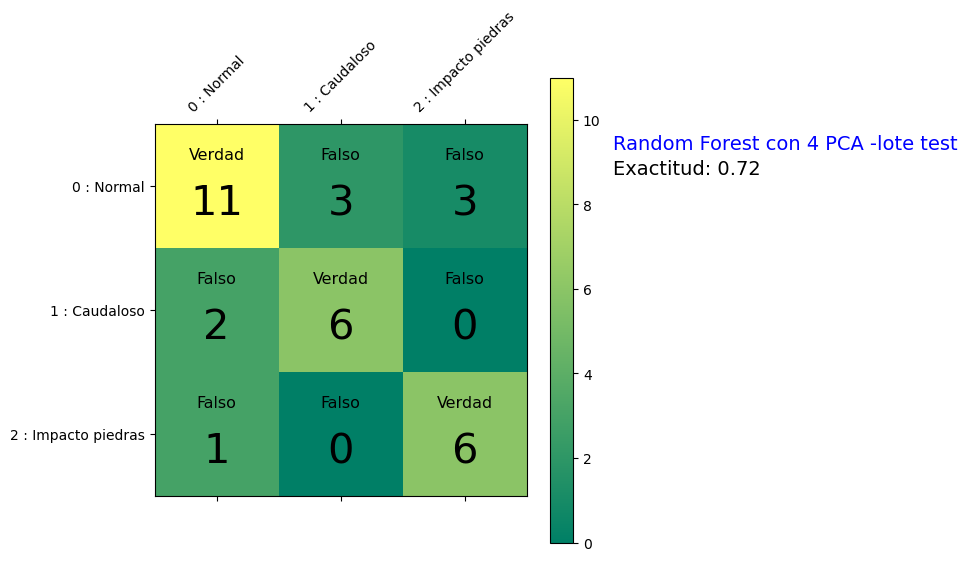

Indice Kappa Random Forest con 4 PCA -lote test: 0.5576036866359446
---------------clasificacion  Random Forest PCA - sobre la totalidad de las observaciones------------------------
La precición de la predicción es:  85.84905660377359 %

Accuracy: 0.858

Loss: 0.142

f1_per_clase: 0.851 0.862 0.868

balanceado accuracy: 0.847

Sensitivity (Recall):0.915 0.833 0.793
[[43  3  1]
 [ 5 25  0]
 [ 6  0 23]]

Presición nor-cau-pie:0.915 0.833 0.793

Specificity nor-cau-pie:0.085 0.167 0.207

G-Mean:0.846

Cohen’s kappa:0.778
43


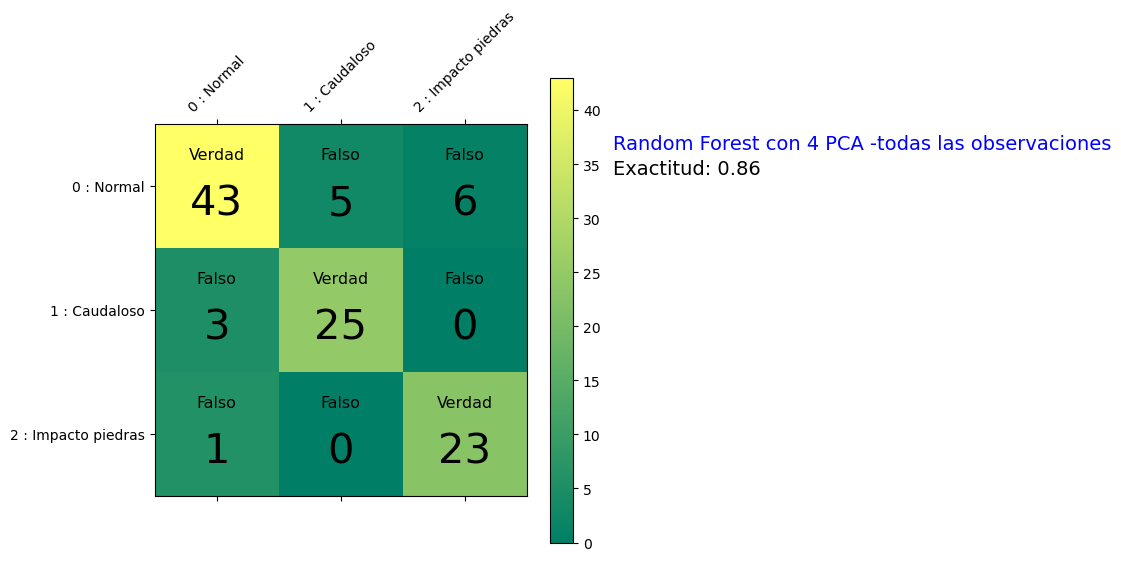

Indice Kappa Random Forest con 4 PCA --todas las observaciones: 0.7779949734710975


In [25]:
# --- Una vez ajustado el modelo se puede utilizar para predecir nuevos valores.
#clf.predict([[2., 2.,3,4,5]])  #jempo para clasificar a partir de 5 caracteristicas
print('---------------clasificacion Random Forest PCA - sobre el lote de test------------------------');
clase_prediccion=bosque.predict(X_test);
print("La precición de la predicción es: ",bosque.score(X_test, y_test)*100,"%");
clase_test=y_test;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,0);
metricas_tabla=np.insert(metricas_tabla, 0, metricas_reg0, axis=0);#debe inciar desde 0 y luego se incrementa
parametros.append("4 PCA, 200  árboles, Entropy");
matriz_de_confusion(y_test, clase_prediccion, "Random Forest con 4 PCA -lote test") 
kappa1=cohen_kappa_score(y_test, clase_prediccion);
print('Indice Kappa Random Forest con 4 PCA -lote test:',kappa1);

print('---------------clasificacion  Random Forest PCA - sobre la totalidad de las observaciones------------------------');
clase_prediccion=bosque.predict(X);
print("La precición de la predicción es: ",bosque.score(X, y)*100,"%");
clase_test=y;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,2);
matriz_de_confusion(y, clase_prediccion, "Random Forest con 4 PCA -todas las observaciones") 
kappa1=cohen_kappa_score(y, clase_prediccion);
print('Indice Kappa Random Forest con 4 PCA --todas las observaciones:',kappa1);

In [24]:
import m2cgen as m2c
code = m2c.export_to_c(bosque) #estim55_depth5_mflog2_4pca_abr2026
#print(code)

<h3>3.3 Aplicación de Random Forest con 8 PCA con lote de entrenamiento y prueba(30%)</h3>

In [26]:
#____________________Clasificador ARbol de decisiones con PCA_______________
print('---------------clasificador ärbol de deciones con PCA------------------------');
datos=resultados_pca[:,0:8] #desde 0 hasta 5 (0,1,2,3,4,5,6,7 ) , los ocho primeros 
#print(datos)
#print(clase)
X=datos;
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
y=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

for max_depth in [3,5,7]:
    rf_tree = RandomForestClassifier(n_estimators=200, max_depth=max_depth, random_state=19, criterion="gini");
    rf_tree.fit(X_train, y_train)
    print(rf_tree.feature_importances_)
    
bosque = RandomForestClassifier(n_estimators=200,max_depth=10,criterion="gini",max_features="sqrt",bootstrap=True,max_samples=2/3,oob_score=True)
bosque.fit(X_train, y_train)

---------------clasificador ärbol de deciones con PCA------------------------
-------preprocesando--------
LabelEncoder()
[0. 1. 2.]
[0.26712858 0.05604293 0.05520309 0.17790686 0.09556821 0.0945525
 0.07174078 0.18185705]
[0.24855508 0.0747124  0.06122664 0.16926424 0.10191426 0.08863049
 0.07994507 0.17575182]
[0.24542128 0.07666456 0.06548369 0.16336348 0.10176393 0.08938863
 0.08754899 0.17036544]


RandomForestClassifier(max_depth=10, max_samples=0.6666666666666666,
                       n_estimators=200, oob_score=True)

---------------clasificacion Random Forest PCA - sobre el lote de test------------------------
La precición de la predicción es:  71.875 %

Accuracy: 0.719

Loss: 0.281

f1_per_clase: 0.727 0.667 0.750

balanceado accuracy: 0.693

Sensitivity (Recall):0.857 0.556 0.667
[[12  1  1]
 [ 4  5  0]
 [ 3  0  6]]

Presición nor-cau-pie:0.857 0.556 0.667

Specificity nor-cau-pie:0.143 0.444 0.333

G-Mean:0.682

Cohen’s kappa:0.551
12


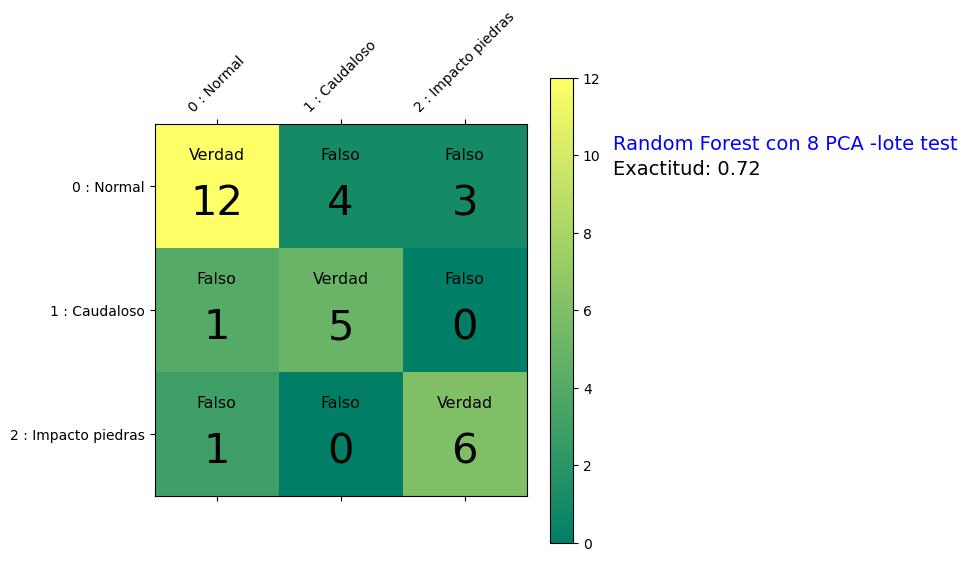

Indice Kappa Random Forest con 8 PCA -lote test: 0.5507020280811232
---------------clasificacion  Random Forest PCA - sobre la totalidad de las observaciones------------------------
La precición de la predicción es:  91.50943396226415 %

Accuracy: 0.915

Loss: 0.085

f1_per_clase: 0.909 0.912 0.929

balanceado accuracy: 0.907

Sensitivity (Recall):0.957 0.867 0.897
[[45  1  1]
 [ 4 26  0]
 [ 3  0 26]]

Presición nor-cau-pie:0.957 0.867 0.897

Specificity nor-cau-pie:0.043 0.133 0.103

G-Mean:0.906

Cohen’s kappa:0.867
45


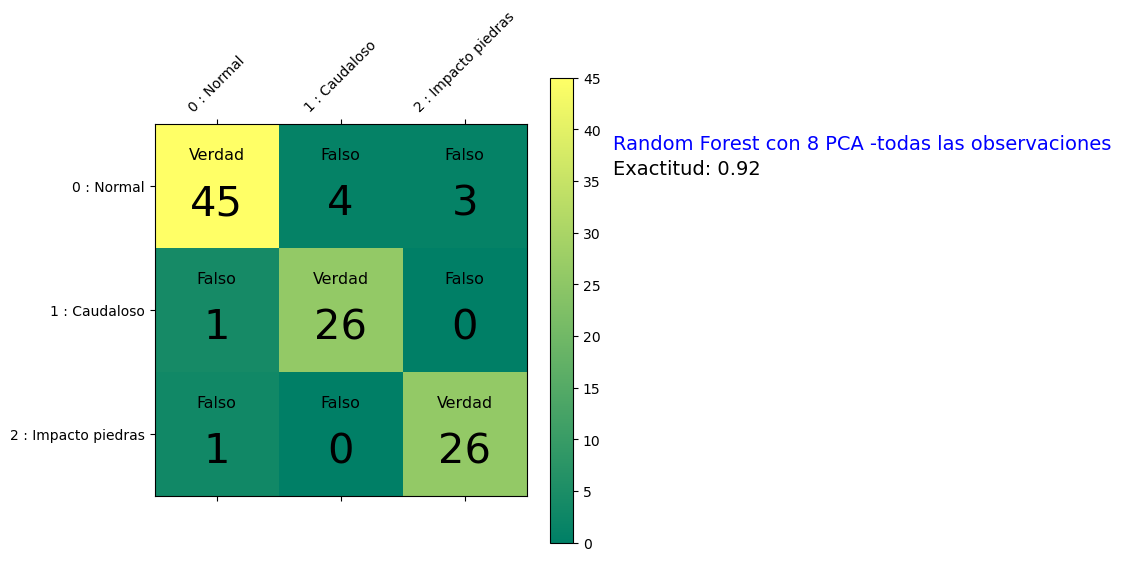

Indice Kappa Random Forest con 8 PCA -todas las observaciones: 0.8674815946659258


In [27]:
# --- Una vez ajustado el modelo se puede utilizar para predecir nuevos valores.
#clf.predict([[2., 2.,3,4,5]])  #jempo para clasificar a partir de 8 caracteristicas
print('---------------clasificacion Random Forest PCA - sobre el lote de test------------------------');
clase_prediccion=bosque.predict(X_test);
print("La precición de la predicción es: ",bosque.score(X_test, y_test)*100,"%");
clase_test=y_test;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,1);
metricas_tabla=np.insert(metricas_tabla, 1, metricas_reg0, axis=0);#debe inciar desde 0 y luego se incrementa
parametros.append("8 PCA, 200  árboles, Entropy");
matriz_de_confusion(y_test, clase_prediccion, "Random Forest con 8 PCA -lote test") 
kappa1=cohen_kappa_score(y_test, clase_prediccion);
print('Indice Kappa Random Forest con 8 PCA -lote test:',kappa1);

print('---------------clasificacion  Random Forest PCA - sobre la totalidad de las observaciones------------------------');
clase_prediccion=bosque.predict(X);
print("La precición de la predicción es: ",bosque.score(X, y)*100,"%");
clase_test=y;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,1);
matriz_de_confusion(y, clase_prediccion, "Random Forest con 8 PCA -todas las observaciones") 
kappa1=cohen_kappa_score(y, clase_prediccion);
print('Indice Kappa Random Forest con 8 PCA -todas las observaciones:',kappa1);

In [28]:
code = m2c.export_to_c(bosque) #bosque_aleatorio2_estim200_depth10_mfsqrt_8pca_abr2026
#print(code)
with open("codigo_exportado_bosques.txt", "w") as archivo:
    print(code, file=archivo)

<h2>4. Aplicación de Random Forest con 5 mejores caracteristicas con lote de entrenamiento y prueba(30%) </h2>

<h3>4.1 Selección de las 5 mejores características con SelectKBest</h3>

Aplicando una funcion que selecciona las cuatro mejores caracteristicas
-------preprocesando--------
LabelEncoder()
[0. 1. 2.]
Después de seleccionar, las cuatro mejores caracteristicas son: (106, 10)

Todas las caracteristicas(77 hasta el momento):
['c1' 'c2' 'c3' 'c4' 'c5' 'c6' 'c7' 'c8' 'c9' 'c10' 'c11' 'c12' 'c13'
 'c14' 'c15' 'c16' 'c17' 'c18' 'c19' 'c20' 'c21' 'c22' 'c23' 'c24' 'c25'
 'c26' 'c27' 'c28' 'c29' 'c30' 'c31' 'c32' 'c33' 'c34' 'c35' 'c36' 'c37'
 'c38' 'c39' 'c40' 'c41' 'c42' 'c43' 'c44' 'c45' 'c46' 'c47' 'c48' 'c49'
 'c50' 'c51' 'c52' 'c53' 'c54' 'c55' 'c56' 'c57' 'c58' 'c59' 'c60' 'c61'
 'c62' 'c63' 'c64' 'c65' 'c66' 'c67' 'c68' 'c69' 'c70' 'c71' 'c72' 'c73'
 'c74' 'c75']

Las 2 mejores selecionadas:
['c5' 'c6' 'c7' 'c8' 'c14' 'c15' 'c16' 'c60' 'c74' 'c75']


Se grafican las mejores características:


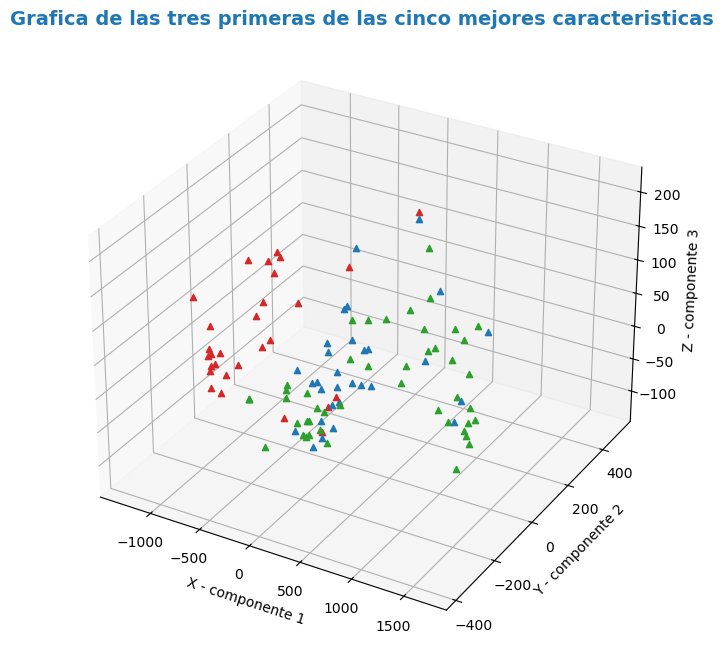

In [10]:
print("Aplicando una funcion que selecciona las cuatro mejores caracteristicas");
df = pd.read_csv('features_16agos2026_sismos_audio_unificado_csv.csv')
df.head(10) #muestra las 10 primeras filas

caracteristicas0= df.to_numpy();
caracteristicas1= caracteristicas0[:,2:col_caract];
clase= caracteristicas0[:,1];
print('-------preprocesando--------');
le = preprocessing.LabelEncoder();
le.fit(clase);
print(le);
print(le.classes_);
clase=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias

select = SelectKBest(score_func=chi2, k=10)
# scale the data to be between 0 and 1,  ya que chi2 solo soporta valores positivos
sc = MinMaxScaler()
caracteristicas_normal_pos = sc.fit_transform(caracteristicas1)
z_mejores_caract = select.fit_transform(caracteristicas_normal_pos,clase) #caracteristicas, clase
print("Después de seleccionar, las cuatro mejores caracteristicas son:", z_mejores_caract.shape) 

filter = select.get_support()
# si agrega otras caracteristicas esto debe cambiar
features0=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10','c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22',
           'c23','c24','c25','c26','c27','c28','c29','c30','c31','c32','c33','c34','c35','c36','c37','c38','c39','c40','c41','c42','c43','c44',
         'c45','c46','c47','c48','c49','c50','c51','c52','c53','c54','c55','c56','c57','c58','c59','c60','c61','c62','c63','c64',
          'c65','c66','c67','c68','c69','c70','c71','c72','c73','c74','c75'];
features=array(features0);
print();
print("Todas las caracteristicas(77 hasta el momento):")
print(features)
print();

print("Las 2 mejores selecionadas:");
print(features[filter]);
print();
#print(z_mejores_caract); 
print();

print("Se grafican las mejores características:");
#ahora se grafican los PCA en plano 3d
fig = plt.figure(figsize=(12,8)) # Set the figure size to 8 inches wide-ancho and 6 inches tall -alto
ax = fig.add_subplot(projection='3d')
cant_filas=len(z_mejores_caract); #--
tipo_avenida=caracteristicas0[:,1];

elemento_clase_normal=0;
elemento_clase_caudaloso=0;
elemento_clase_impacto=0;
for i in range(cant_filas):
    if (tipo_avenida[i]==0):
        elemento_clase_normal=elemento_clase_normal+1;
    if (tipo_avenida[i]==1):
        elemento_clase_caudaloso=elemento_clase_caudaloso+1;
    if (tipo_avenida[i]==2):
        elemento_clase_impacto=elemento_clase_impacto+1;
for i in range(cant_filas):
    xs = resultados_pca[i,0];
    ys = resultados_pca[i,1];
    zs = resultados_pca[i,2];
    if (tipo_avenida[i]==0):
        ax.scatter(xs, ys, zs, marker='^', color = 'tab:green')
    if (tipo_avenida[i]==1):
        ax.scatter(xs, ys, zs, marker='^', color = 'tab:blue')
    if (tipo_avenida[i]==2):
       ax.scatter(xs, ys, zs, marker='^', color = 'tab:red')
        
ax.set_xlabel('X - componente 1');
ax.set_ylabel('Y - componente 2');
ax.set_zlabel('Z - componente 3');
plt.title('Grafica de las tres primeras de las cinco mejores caracteristicas', loc = "center", fontdict = {'fontsize':14, 'fontweight':'bold', 'color':'tab:blue'});
plt.show()

<h3>4.2 Módelo de optimización</h3>

In [11]:
class ModelOptimization:
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def optimize(self, trial):
    
        # Definition of space search
        criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
        n_estimators = trial.suggest_int('n_estimators', 10, 300)
        max_depth = trial.suggest_int('max_depth', 2, 20)
        max_features=trial.suggest_categorical('max_features',['sqrt', 'log2', None])
        bootstrap= trial.suggest_categorical('bootstrap',[True,False])
        # Classifier definition
        model = RandomForestClassifier(n_estimators=n_estimators,
                                    max_depth=max_depth,
                                    criterion=criterion,max_features=max_features,bootstrap=bootstrap)
    
        avg_accuracy = []

        # Definition of k-fold cross validation
        k_fold = KFold(n_splits=5)
    
        for train_idx, test_idx in k_fold.split(x, y):
            
            # Training fold
            x_train = x[train_idx]
            y_train = y[train_idx]
            
            # Testing fold
            x_test = x[test_idx]
            y_test = y[test_idx]
    
            # Training
            model.fit(x_train, y_train)
    
            # Save accuracy
            avg_accuracy.append(model.score(x_test, y_test))
        
        return np.mean(avg_accuracy)
    
    def train_optimal_configuration(self, best_params):

        # Classifier definition with optimal paramters
        model = RandomForestClassifier(n_estimators=best_params['n_estimators'],
                                    max_depth=best_params['max_depth'],
                                    criterion=best_params['criterion'],
                                    max_features=best_params['max_features'],
                                      bootstrap=best_params['bootstrap'])
        return model.fit(self.x, self.y)

In [12]:
if __name__ == '__main__':

    # Load data and split into train and test sets
    #datos=resultados_pca[:,0:4] #desde 0 hasta 5 (0,1,2,3 ) , los cuatro primeros suman el 96%
    #x=datos;
    x=z_mejores_caract;
    print('-------preprocesando--------');
    le = preprocessing.LabelEncoder();
    le.fit(clase);
    print(le);
    print(le.classes_);
    y=le.transform(clase); #con esto se tranforman las etiquetas de numeros a categorias
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=23)

    # Initialize the optimization model class
    modelOpt = ModelOptimization(x=x_train, y=y_train)

    # Study initialization
    # direction = 'maximize' : since the goal is to maximize the accuracy
    # sampler = 'TPEsampler' : default paramter for single-objective optimization
    # pruner = 'MedianPruner' : default paramter for pruning useless configurations
    study = optuna.create_study(direction='maximize')

    # Opimization
    # Recevies the function to be optimized and the number of trials
    study.optimize(modelOpt.optimize, n_trials=200) #estaba en n_trials=20

    # Since we aimed to maximize accuracy, prints the best 
    # accuracy obtained as well as the best configuration
    print(f"Best average accuracy: {study.best_value}")
    print(f"Best parameters: {study.best_params}")

    # Trains a model with the optimal parameters
    optimal_model = modelOpt.train_optimal_configuration(study.best_params)

    # Print final results
    print(f"Train score: {optimal_model.score(x_train, y_train)}")
    print(f"Test score: {optimal_model.score(x_test, y_test)}")

[I 2026-07-17 00:32:45,549] A new study created in memory with name: no-name-a4ddb45b-3e7e-4fe3-9264-49f6b36ff6fb


-------preprocesando--------
LabelEncoder()
[0 1 2]


[I 2026-07-17 00:32:47,865] Trial 0 finished with value: 0.8004329004329005 and parameters: {'criterion': 'gini', 'n_estimators': 246, 'max_depth': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.8004329004329005.
[I 2026-07-17 00:32:49,780] Trial 1 finished with value: 0.7718614718614718 and parameters: {'criterion': 'entropy', 'n_estimators': 238, 'max_depth': 12, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.8004329004329005.
[I 2026-07-17 00:32:52,310] Trial 2 finished with value: 0.7718614718614718 and parameters: {'criterion': 'gini', 'n_estimators': 261, 'max_depth': 4, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.8004329004329005.
[I 2026-07-17 00:32:53,963] Trial 3 finished with value: 0.7813852813852813 and parameters: {'criterion': 'entropy', 'n_estimators': 164, 'max_depth': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.8004329004329005.
[I 2026-07-17 00:32:54

Best average accuracy: 0.8004329004329005
Best parameters: {'criterion': 'gini', 'n_estimators': 246, 'max_depth': 7, 'max_features': 'log2', 'bootstrap': True}
Train score: 1.0
Test score: 1.0


<h3>4.3 Aplicación del árbol de decisiones con las 5 mejores características</h3>

---------------clasificacion Random Forest 5 mejores caract - sobre el lote de test------------------------
La precición de la predicción es:  100.0 %

Accuracy: 1.000

Loss: 0.000

f1_per_clase: 1.000 1.000 1.000

balanceado accuracy: 1.000

Sensitivity (Recall):1.000 1.000 1.000
[[13  0  0]
 [ 0  8  0]
 [ 0  0 11]]

Presición nor-cau-pie:1.000 1.000 1.000

Specificity nor-cau-pie:0.000 0.000 0.000

G-Mean:1.000

Cohen’s kappa:1.000
13


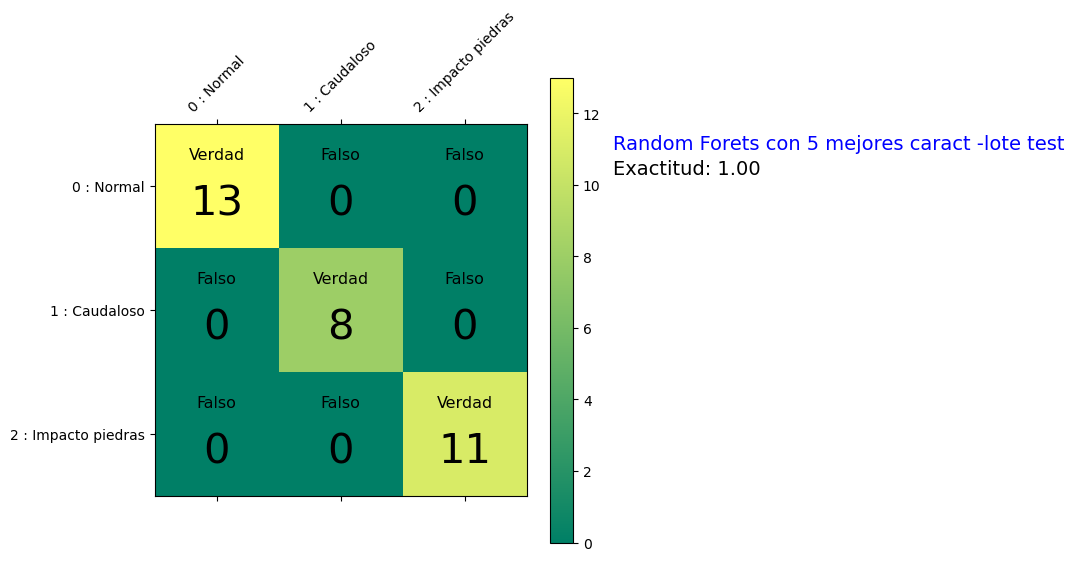

Indice Kappa Random Forest con 5 mejores caracteristicas -lote test: 1.0
---------------clasificacion Random Forest 5 mejores caract - sobre la totalidad de las observaciones------------------------
La precición de la predicción es:  100.0 %
47


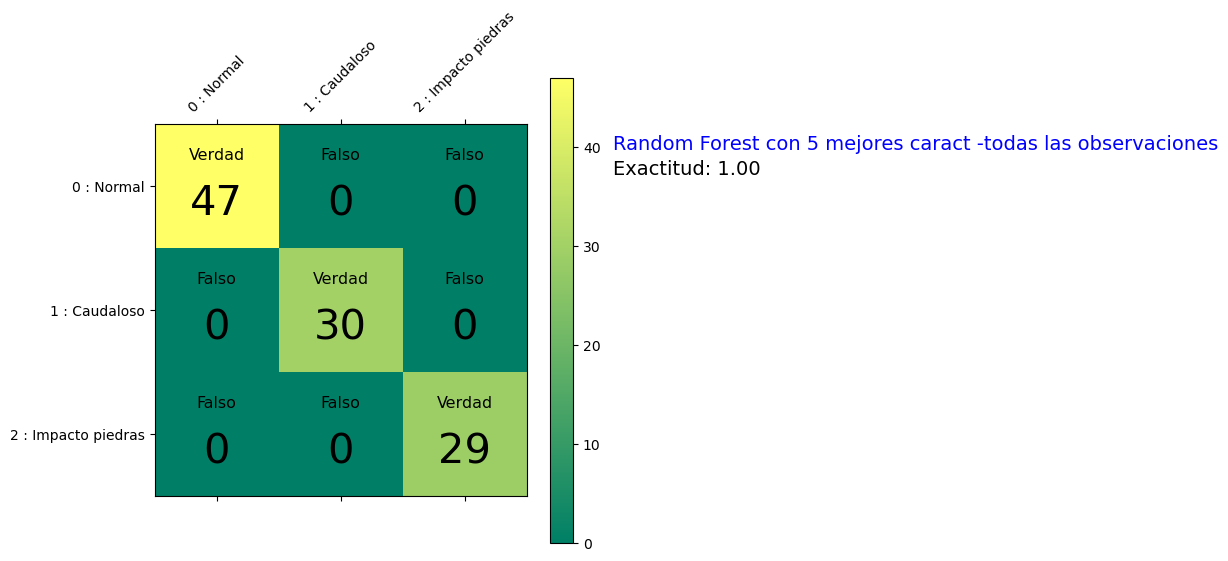

Indice Kappa Random Forest con 5 mejores caract -todas las observaciones: 1.0


In [13]:
# --- Una vez ajustado el modelo se puede utilizar para predecir nuevos valores.
print('---------------clasificacion Random Forest 5 mejores caract - sobre el lote de test------------------------');
clase_prediccion=optimal_model.predict(x_test);
print("La precición de la predicción es: ",optimal_model.score(x_test, y_test)*100,"%");
clase_test=y_test;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,2);
metricas_tabla=np.insert(metricas_tabla, 2, metricas_reg0, axis=0);#debe inciar desde 0 y luego se incrementa
parametros.append("4 carac,200 árboles");
matriz_de_confusion(y_test, clase_prediccion, "Random Forets con 5 mejores caract -lote test") 
kappa1=cohen_kappa_score(y_test, clase_prediccion);
print('Indice Kappa Random Forest con 5 mejores caracteristicas -lote test:',kappa1);

print('---------------clasificacion Random Forest 5 mejores caract - sobre la totalidad de las observaciones------------------------');
clase_prediccion=optimal_model.predict(x);
print("La precición de la predicción es: ",optimal_model.score(x, y)*100,"%");
matriz_de_confusion(y, clase_prediccion, "Random Forest con 5 mejores caract -todas las observaciones") 
kappa1=cohen_kappa_score(y, clase_prediccion);
print('Indice Kappa Random Forest con 5 mejores caract -todas las observaciones:',kappa1);

In [34]:
code = m2c.export_to_c(bosque) #bosque_aleatorio3_estim200_depth10_mfsqrt_5best_abr2026
#bosque_aleatorio4_estim50_depth10_mflog2_5best_abr2026
#bosque_aleatorio5_estim10_depth10_mfsqrt_5best_abr2026
#print(code)
with open("codigo_exportado_bosques.txt", "w") as archivo:
    print(code, file=archivo)

<h2>5. Aplicación de Random Forest con 77 caracteristicas con lote de entrenamiento y prueba(30%) </h2>

In [91]:
print('---------------clasificador Random Forest con 10 mejores caracteristicas------------------------');
datos=caracteristicas1; 
X=datos;
y=clase;
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

bosque = RandomForestClassifier(n_estimators=250,max_depth= 10,criterion="gini",max_features="sqrt",bootstrap=True,max_samples=3/4,oob_score=True)
bosque.fit(X_train, y_train)

---------------clasificador Random Forest con 10 mejores caracteristicas------------------------


RandomForestClassifier(max_depth=10, max_samples=0.75, n_estimators=250,
                       oob_score=True)

---------------clasificacion Random Forest 45 caract - sobre el lote de test------------------------
La precición de la predicción es:  81.25 %

Accuracy: 0.812

Loss: 0.188

f1_per_clase: 0.800 0.778 0.875

balanceado accuracy: 0.804

Sensitivity (Recall):0.857 0.778 0.778
[[12  2  0]
 [ 2  7  0]
 [ 2  0  7]]

Presición nor-cau-pie:0.857 0.778 0.778

Specificity nor-cau-pie:0.143 0.222 0.222

G-Mean:0.803

Cohen’s kappa:0.707
12


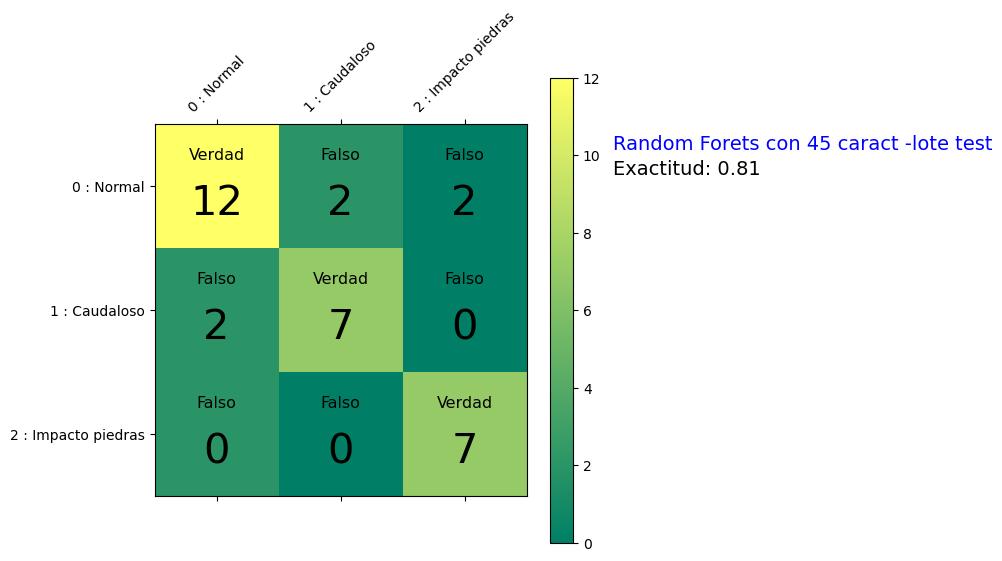

Indice Kappa Random Forest con 45 caracteristicas -lote test: 0.7073170731707317
---------------clasificacion Random Forest 45 caract - sobre la totalidad de las observaciones------------------------
La precición de la predicción es:  94.33962264150944 %

Accuracy: 0.943

Loss: 0.057

f1_per_clase: 0.938 0.933 0.964

balanceado accuracy: 0.941

Sensitivity (Recall):0.957 0.933 0.931
[[45  2  0]
 [ 2 28  0]
 [ 2  0 27]]

Presición nor-cau-pie:0.957 0.933 0.931

Specificity nor-cau-pie:0.043 0.067 0.069

G-Mean:0.941

Cohen’s kappa:0.912
45


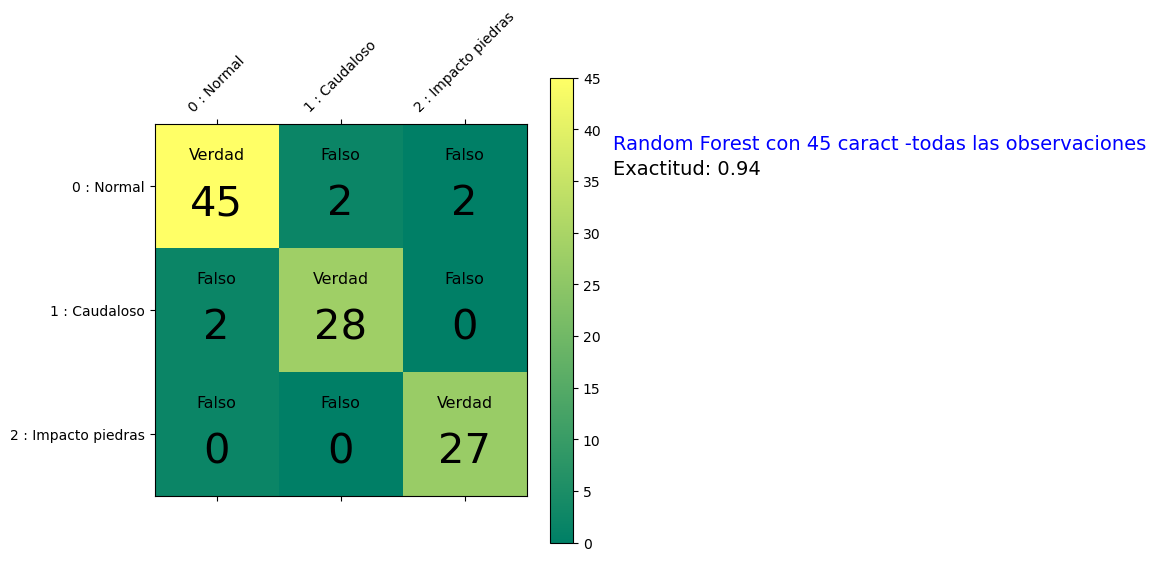

Indice Kappa Random Forest con 45 caracteristicas -lote test: 0.9122758620689655


In [92]:
# --- Una vez ajustado el modelo se puede utilizar para predecir nuevos valores.
print('---------------clasificacion Random Forest 45 caract - sobre el lote de test------------------------');
clase_prediccion=bosque.predict(X_test);
print("La precición de la predicción es: ",bosque.score(X_test, y_test)*100,"%");
clase_test=y_test;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,3);
metricas_tabla=np.insert(metricas_tabla, 3, metricas_reg0, axis=0);#debe inciar desde 0 y luego se incrementa
parametros.append("45 carac,100 árboles");
matriz_de_confusion(y_test, clase_prediccion, "Random Forets con 45 caract -lote test") 
kappa1=cohen_kappa_score(y_test, clase_prediccion);
print('Indice Kappa Random Forest con 45 caracteristicas -lote test:',kappa1);

print('---------------clasificacion Random Forest 45 caract - sobre la totalidad de las observaciones------------------------');
clase_prediccion=bosque.predict(X);
print("La precición de la predicción es: ",bosque.score(X, y)*100,"%");
clase_test=y;
metricas_reg0=calcular_metricas(clase_test, clase_prediccion,3);
matriz_de_confusion(y, clase_prediccion, "Random Forest con 45 caract -todas las observaciones") 
kappa1=cohen_kappa_score(y, clase_prediccion);
print('Indice Kappa Random Forest con 45 caracteristicas -lote test:',kappa1);

In [ ]:
code = m2c.export_to_c(bosque) 
#bosque_aleatorio8_estim50_depth6_mfsqrt_22feat_abr2026
#bosque_aleatorio9_estim10_depth6_mflog2_22feat_abr2026
#print(code)
with open("codigo_exportado_bosques.txt", "w") as archivo:
    print(code, file=archivo)
